# **Diplomado IA: Aplicaciones 1 - NLP**. <br> Práctico 20: Modelos de lenguaje (ElMo, BERT, GPT2, ChatGPT)
---
---

**Profesor:**
- Carlos Aspillaga

---
---

# **Instrucciones Generales**

El siguiente práctico se debe realizar **individualmente**. El formato de entrega es el **archivo .ipynb con todas las celdas ejecutadas**. Todas las preguntas deben ser respondidas en las celdas dispuestas para ello. No se aceptará el _output_ de una celda de código como respuesta.

**Nombre Alumno:** Javier Rojas Benitez


El siguiente práctico cuenta con 4 partes y contendrá actividades a realizar.

**IMPORTANTE: habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0**

# **Índice**

>[Diplomado IA: Aplicaciones 1 - NLP.  Práctico 20: Modelos de lenguaje (ElMo, BERT, GPT2, ChatGPT)](#scrollTo=tHopPtVaNF1K)

>[Instrucciones Generales](#scrollTo=D4--58EgLXxI)

>[Índice](#scrollTo=jCb8075QLdVx)

>[Librería "Transformers", de Huggingface](#scrollTo=XmRz5CaMDuNJ)

>>[Instalación de dependencias](#scrollTo=WAl2ZQQ3Lm9R)

>>[Uso básico de la librería](#scrollTo=IEf542-yNkLX)

>>[Actividad](#scrollTo=rzmdJB4EObaw)

>[Actividad](#scrollTo=bcD8Svj9HGuQ)

>[BERT](#scrollTo=TUoT7x1uNu0i)

>>[Finetuning de BERT para detectar Fake News](#scrollTo=9D9wMxO7NDAy)

>[GPT-2](#scrollTo=uCE6qym-NxJs)

>>[GPT-2: Generación de texto](#scrollTo=sQI4zJORMjkX)

>>[Actividades](#scrollTo=rKftFZ2W4XKJ)

>[Actividad Final](#scrollTo=Acvhf7xiPN1W)



# **Librería "Transformers", de Huggingface**

## Instalación de dependencias

In [1]:
!pip install -q transformers==4.56.2
!pip install -q sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 109.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


❗❗❗❗**OJO: Google Colab podría solicitar reiniciar el entorno de ejecución para que la instalación tome efecto**
Entorno de ejecución > Reiniciar entorno de ejecución

## Uso básico de la librería

La librería "Transformers" de Huggingface es una librería opensource que se ha encargado de facilitar el uso de los modelos basados en transformer. Incluye prácticamente todos los modelos principales y está en constante actualización (actualmente tiene 33 + varios otros contrinuidos por la comunidad).

Aquí puede ver todas las arquitecturas soportadas: https://huggingface.co/transformers/index.html

Aquí puede ver todos los pesos preentrenados disponibles:
https://huggingface.co/transformers/pretrained_models.html

Aquí puede ver ejemplos de código ejecutando las tareas más comunes: https://github.com/huggingface/transformers/tree/master/examples/pytorch

A continuación veremos un ejemplo de uso de un modelo cualquiera, que debería ser muy similar a casi todos los modelos disponibles en la librería.

In [2]:
from transformers import XLNetTokenizer, XLNetModel
import torch

tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')
model = XLNetModel.from_pretrained('xlnet-base-cased', return_dict=True)

inputs = tokenizer("Hello, my dog is cute", return_tensors="pt")
outputs = model(**inputs)

last_hidden_states = outputs.last_hidden_state

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

In [6]:
from transformers import XLNetTokenizer, XLNetForQuestionAnswering
import torch

tokenizer =  XLNetTokenizer.from_pretrained('xlnet-base-cased')
model = XLNetForQuestionAnswering.from_pretrained('xlnet-base-cased', return_dict=True)

input_ids = torch.tensor(tokenizer.encode("Hello, my dog is cute", add_special_tokens=True)).unsqueeze(0)  # Batch size 1
start_positions = torch.tensor([1])
end_positions = torch.tensor([3])
outputs = model(input_ids, start_positions=start_positions, end_positions=end_positions)

loss = outputs.loss

Some weights of XLNetForQuestionAnswering were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['answer_class.dense_0.bias', 'answer_class.dense_0.weight', 'answer_class.dense_1.weight', 'end_logits.LayerNorm.bias', 'end_logits.LayerNorm.weight', 'end_logits.dense_0.bias', 'end_logits.dense_0.weight', 'end_logits.dense_1.bias', 'end_logits.dense_1.weight', 'start_logits.dense.bias', 'start_logits.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
from transformers import XLNetTokenizer, XLNetForMultipleChoice
import torch

tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')
model = XLNetForMultipleChoice.from_pretrained('xlnet-base-cased', return_dict=True)

prompt = "In Italy, pizza served in formal settings, such as at a restaurant, is presented unsliced."
choice0 = "It is eaten with a fork and a knife."
choice1 = "It is eaten while held in the hand."
labels = torch.tensor(0).unsqueeze(0)  # choice0 is correct (according to Wikipedia ;)), batch size 1

encoding = tokenizer([[prompt, prompt], [choice0, choice1]], return_tensors='pt', padding=True)
outputs = model(**{k: v.unsqueeze(0) for k,v in encoding.items()}, labels=labels)  # batch size is 1

# the linear classifier still needs to be trained
loss = outputs.loss
logits = outputs.logits

Some weights of XLNetForMultipleChoice were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


##Actividad

Para esta actividad tendrá que revisar la documentación de Huggingface para el modelo RoBERTa, que es un modelo oficial liberado por FacebookAI. Nos interesa que usted sea capaz de hacer esto pues en el futuro posiblemente nazcan modelos superiores a los vistos en clase y usted quiera poder usarlos.

En el espacio dispuesto más abajo, escriba (o copie-pegue) la(s) línea(s) de código necesaria(s) para crear el modelo en su versión basica (es decir, no especializado en QuestionAnswering, MultipleChoice, ni nada por el estilo), cargar sus pesos preentrenados, tokenizar, y generar el output. No olvide los imports necesarios

Debe importar el modelo oficial (el original de FacebookAI) en tamaño base.

Está totalmente permitido usar una versión distinta de la libreria (distinta a la que usamos en este lab), pero recuerde que para hacerlo deberá instalarla con pip

**1) Escriba aquí las líneas de código necesarias para crear el modelo y cargar los pesos preentrenados. No olvide los imports necesarios**

In [8]:
# Escriba aquí el codigo con su respuesta
from transformers import RobertaModel
import torch

model = RobertaModel.from_pretrained('FacebookAI/roberta-base', return_dict=True)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**2) Escriba aquí la linea de código necesaria para crear el tokenizador. No olvide los imports necesarios**

In [14]:
# Escriba aquí el codigo con su respuesta
from transformers import RobertaTokenizer
import torch

tokenizer = RobertaTokenizer.from_pretrained('FacebookAI/roberta-base')

**3) Escriba aquí la(s) líneas de código necesarias para tokenizar la oración "Hello World!"**

In [10]:
text = "Hello World!"
# Escriba aquí el codigo con su respuesta
inputs = tokenizer(text, return_tensors="pt")
print(inputs)

{'input_ids': tensor([[    0, 31414,   623,   328,     2]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}


**4) Escriba aquí la(s) líneas de código necesarias para ejecutar el modelo sobre la oración tokenizada**

In [11]:
# Escriba aquí el codigo con su respuesta
outputs = model(**inputs)

last_hidden_states = outputs.last_hidden_state

# Actividad

Para esta siguiente actividad, tendrá que revisar la documentación de Huggingface para el tomar un modelo oficial y cargarle los pesos liberados por la comunidad. Trabajaremos sobre los pesos de BETO (dccuchile).

En el espacio dispuesto más abajo, escriba (o copie-pegue) la(s) línea(s) de código necesaria(s) para crear el modelo en su versión basica (es decir, no especializado en QuestionAnswering, MultipleChoice, ni nada por el estilo), cargar sus pesos preentrenados, tokenizar, y generar el output. No olvide los imports necesarios

Está totalmente permitido usar una versión distinta de la libreria (distinta a la que usamos en este lab), pero recuerde que para hacerlo deberá instalarla con pip

**5) Escriba aquí las líneas de código necesarias para crear el modelo y cargar los pesos preentrenados. No olvide los imports necesarios**

In [ ]:
# Escriba aquí el codigo con su respuesta
from transformers import BertModel
import torch

model = BertModel.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased', return_dict=True)

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

**6) Escriba aquí las lineas de código necesarias para crear el tokenizador. No olvide los imports necesarios**

In [16]:
# Escriba aquí el codigo con su respuesta
from transformers import BertTokenizer
import torch

tokenizer = BertTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-uncased')

tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

**7) Escriba aquí la(s) líneas de código necesarias para tokenizar la oración "Hola Mundo!"**

In [17]:
text = "Hola Mundo!"
# Escriba aquí el codigo con su respuesta
inputs = tokenizer(text, return_tensors="pt")
print(inputs)

{'input_ids': tensor([[   4, 1734, 1758, 1109,    5]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1]])}


**8) Escriba aquí la(s) líneas de código necesarias para ejecutar el modelo sobre la oración tokenizada**

In [18]:
# Escriba aquí el codigo con su respuesta
outputs = model(**inputs)

last_hidden_states = outputs.last_hidden_state

# **BERT**

##Finetuning de BERT para detectar Fake News

Parcialmente basado en el tutorial de https://towardsdatascience.com/bert-text-classification-using-pytorch-723dfb8b6b5b

Dataset https://www.kaggle.com/nopdev/real-and-fake-news-dataset

Preprocesamiento:

*  Eliminación de textos cortos (<5 palabras)
*  Concatenación de titulo + texto (separado por un punto)
*  Truncamiento de textos largos a máximo 200 caracteres
*  FAKE = 1, REAL = 0
*  Split de train (80%), dev (10%) y test (10%)

In [19]:
!if [ ! -f news.csv ]; then wget -q https://www.dropbox.com/s/5pfv1td1oyj611w/news.csv; fi

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertForSequenceClassification
import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import os

# Leer CSV original
df_raw = pd.read_csv('news.csv')

# Preparar columnas
df_raw['label'] = (df_raw['label'] == 'FAKE').astype('int')
df_raw['titletext'] = df_raw['title'] + ". " + df_raw['text']
df_raw = df_raw.reindex(columns=['label', 'title', 'text', 'titletext'])

# Eliminar textos muy cortos y truncar textos muy largos
df_raw.drop(df_raw[df_raw.text.str.len() < 5].index, inplace=True)
df_raw['text'] = df_raw['text'].apply(lambda x: ' '.join(x.split(maxsplit=200)[:200]))
df_raw['titletext'] = df_raw['titletext'].apply(lambda x: ' '.join(x.split(maxsplit=200)[:200]))

# Separar por clase, para dividir train-val-test de manera balanceada
df_real = df_raw[df_raw['label'] == 0]
df_fake = df_raw[df_raw['label'] == 1]

# Dividir en train-val y test a razon 80%/10%/10%
df_real_train, df_real_full_test = train_test_split(df_real, train_size = 0.8, random_state = 1)
df_fake_train, df_fake_full_test = train_test_split(df_fake, train_size = 0.8, random_state = 1)
df_real_test, df_real_valid = train_test_split(df_real_full_test, train_size = 0.5, random_state = 1)
df_fake_test, df_fake_valid = train_test_split(df_fake_full_test, train_size = 0.5, random_state = 1)
df_train = pd.concat([df_real_train, df_fake_train], ignore_index=True, sort=False)
df_valid = pd.concat([df_real_valid, df_fake_valid], ignore_index=True, sort=False)
df_test = pd.concat([df_real_test, df_fake_test], ignore_index=True, sort=False)

# Guardar resultado como CSV
df_train.to_csv('news_train.csv', index=False)
df_valid.to_csv('news_val.csv', index=False)
df_test.to_csv('news_test.csv', index=False)

In [21]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [22]:
from torch.utils.data import DataLoader, Dataset

class CsvDataset(Dataset):
  def __init__(self, csv_file, tokenizer, max_len=512):
    self.df = pd.read_csv(csv_file)
    self.tokenizer = tokenizer
    self.max_len = max_len

    self.labels = self.df.iloc[:,0]
    self.titletexts = self.df.iloc[:,3]

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    label = self.labels[idx]
    titletext = self.titletexts[idx]

    tokenized_text = self.tokenizer(titletext,
                                      padding='max_length',  # Pad to max_length
                                      truncation=True,  # Truncate to max_length
                                      max_length=self.max_len,
                                      return_tensors='pt')['input_ids']

    return label, tokenized_text

In [23]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Parametros del modelo
MAX_SEQ_LEN = 128

# Crear el dataset
train_dataset = CsvDataset('news_train.csv', tokenizer, max_len=MAX_SEQ_LEN)
dev_dataset = CsvDataset('news_val.csv', tokenizer, max_len=MAX_SEQ_LEN)
test_dataset = CsvDataset('news_test.csv', tokenizer, max_len=MAX_SEQ_LEN)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, num_workers=1, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=16, num_workers=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, num_workers=1, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [24]:
def train(model,
          optimizer,
          criterion = nn.BCELoss(),
          train_loader = train_loader,
          valid_loader = dev_loader,
          num_epochs = 5,
          eval_every = len(train_loader) // 2,
          file_path = 'temp_results',
          best_valid_loss = float("Inf")):

    if not os.path.exists(file_path):
        os.makedirs(file_path)

    # inicializar contadores
    running_loss = 0.0
    valid_running_loss = 0.0
    global_step = 0
    train_loss_list = []
    valid_loss_list = []
    global_steps_list = []

    # loop de entrenamento
    model.train()
    for epoch in range(num_epochs):
        for labels, titletext in train_loader:
            labels = labels.type(torch.LongTensor).unsqueeze(1)
            labels = labels.to(device)
            titletext = titletext.type(torch.LongTensor).squeeze(1)
            titletext = titletext.to(device)
            loss, predictions = model(titletext, labels=labels)[:2]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # actualizar conteos
            running_loss += loss.item()
            global_step += 1

            # evaluacion
            if global_step % eval_every == 0:
                model.eval()
                with torch.no_grad():

                    # validacion
                    for labels, titletext in valid_loader:
                        labels = labels.type(torch.LongTensor).unsqueeze(1)
                        labels = labels.to(device)
                        titletext = titletext.type(torch.LongTensor).squeeze(1)
                        titletext = titletext.to(device)
                        loss, predictions = model(titletext, labels=labels)[:2]

                        valid_running_loss += loss.item()

                # evaluacion
                average_train_loss = running_loss / eval_every
                average_valid_loss = valid_running_loss / len(valid_loader)
                train_loss_list.append(average_train_loss)
                valid_loss_list.append(average_valid_loss)
                global_steps_list.append(global_step)

                # resetear conteos de la epoca
                running_loss = 0.0
                valid_running_loss = 0.0
                model.train()

                # imprimir resultados hasta el momento
                print('Epoch [{}/{}], Step [{}/{}], Train Loss: {:.4f}, Valid Loss: {:.4f}'
                      .format(epoch+1, num_epochs, global_step, num_epochs*len(train_loader),
                              average_train_loss, average_valid_loss))

                # checkpoint
                if best_valid_loss > average_valid_loss:
                    best_valid_loss = average_valid_loss
                    save_checkpoint(file_path + '/' + 'model.pt', model, best_valid_loss)

    print('Finished Training!')

def save_checkpoint(save_path, model, valid_loss):
    if save_path == None:
        return
    state_dict = {'model_state_dict': model.state_dict(),
                  'valid_loss': valid_loss}
    torch.save(state_dict, save_path)
    print(f'Model saved to ==> {save_path}')

def load_checkpoint(load_path, model):
    if load_path==None:
        return
    state_dict = torch.load(load_path, map_location=device)
    print(f'Model loaded from <== {load_path}')
    model.load_state_dict(state_dict['model_state_dict'])
    return state_dict['valid_loss']

In [25]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2, return_dict=False)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)

train(model=model, optimizer=optimizer, num_epochs=1)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Epoch [1/1], Step [157/315], Train Loss: 0.2590, Valid Loss: 0.1453
Model saved to ==> temp_results/model.pt
Epoch [1/1], Step [314/315], Train Loss: 0.1335, Valid Loss: 0.2277
Finished Training!


In [26]:
# Evaluation Function

def evaluate(model, test_loader):
    y_pred = []
    y_true = []

    model.eval()
    with torch.no_grad():
        for labels, titletext in test_loader:

                labels = labels.type(torch.LongTensor).unsqueeze(1)
                labels = labels.to(device)
                titletext = titletext.type(torch.LongTensor).squeeze(1)
                titletext = titletext.to(device)
                loss, predictions = model(titletext, labels=labels)[:2]
                y_pred.extend(torch.argmax(predictions, 1).tolist())
                y_true.extend(labels.tolist())

    print('Classification Report:')
    print(classification_report(y_true, y_pred, labels=[1,0], digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[1,0])
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax, cmap='Blues', fmt="d")

    ax.set_title('Confusion Matrix')

    ax.set_xlabel('Predicted Labels')
    ax.set_ylabel('True Labels')

    ax.xaxis.set_ticklabels(['FAKE', 'REAL'])
    ax.yaxis.set_ticklabels(['FAKE', 'REAL'])

Model loaded from <== temp_results/model.pt
Classification Report:
              precision    recall  f1-score   support

           1     0.9607    0.9361    0.9482       313
           0     0.9385    0.9621    0.9502       317

    accuracy                         0.9492       630
   macro avg     0.9496    0.9491    0.9492       630
weighted avg     0.9495    0.9492    0.9492       630



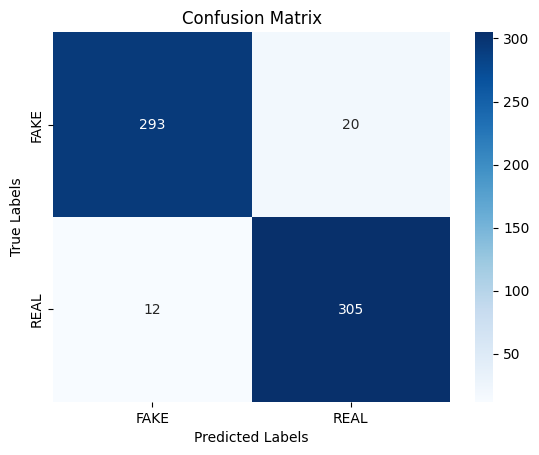

In [27]:
load_checkpoint('temp_results/model.pt', model)

evaluate(model, test_loader)

# **GPT-2**

## GPT-2: Generación de texto

En la siguiente actividad, generaremos texto usaremos GPT2 preentrenado.

Si bien estaremos usando los pesos preentrenados de la versión pequeña (gpt2) puede usar también la versión grande (gpt2-xl).

Adicionalmente también es posible hacer finetuning de GPT2 para que genere textos según lo que usted requiera. Un tutorial para eso puede encontrarse en https://towardsdatascience.com/fine-tuning-gpt2-for-text-generation-using-pytorch-2ee61a4f1ba7

Primero instalaremos la librería (en caso de no estar instalada)

In [28]:
!pip install -q transformers==4.56.2

In [29]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# add the EOS token as PAD token to avoid warnings
model = GPT2LMHeadModel.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

A continuación podemos generar un texto usando el modelo GPT2. Solamente le tenemos que entregar una frase inicial, y el modelo luego entrega una posible continuación para el texto.

In [30]:
input_ids = tokenizer.encode('I enjoy walking with my cute dog', return_tensors='pt')

beam_output = model.generate(
    input_ids,
    attention_mask=torch.ones(input_ids.shape, dtype=torch.long),
    max_length=100,
    num_beams=4,
    early_stopping=True
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I'm not sure if I'll ever be able to walk with him again.

I


Vemos que no genera un texto del todo convincente, pues tiene muchas repeticiones (lo cual es muy usual en este tipo de modelos). Para resolver eso podemos restringir que no repita ciertos ngrams de la siguiente forma:

In [31]:
input_ids = tokenizer.encode('I enjoy walking with my cute dog', return_tensors='pt')

beam_output = model.generate(
    input_ids,
    attention_mask=torch.ones(input_ids.shape, dtype=torch.long),
    max_length=100,
    num_beams=5,
    no_repeat_ngram_size=3,
    early_stopping=True
)

print("Output:\n" + 100 * '-')
print(tokenizer.decode(beam_output[0], skip_special_tokens=True))

Output:
----------------------------------------------------------------------------------------------------
I enjoy walking with my cute dog, but I'm not sure if I'll ever be able to walk with him again.

I've been doing this for a few years now, and I love it. It's a great way to spend time with your dog, and it's one of the best things I've ever done. I've also been doing it for a couple of years now and I'm really happy with it. I think it's the best thing that ever happened to me


## Actividades

**9) Como ha visto a lo largo de este laboratorio, cada modelo trae su propio tokenizador. ¿Qué efecto tendría si usáramos el tokenizador de un modelo (ejemplo: el de BERT) para otro (ejemplo: para GPT2)?. Explique muy brevemente el efecto que podría tener en los resultados, asumiendo que solo se usará en modo "inferencia", no en modo "entrenamiento" ni "finetuning", y que el código ejecuta sin errores.**

Escriba aquí su respuesta

Utilizar un tokenizador de otro modelo puede ser altamente perjudicial al momento de utilizar un modelo. Esto, principalmente por:

1. Puede que exista diferencia en la forma de tokenizar ciertas palabras entre modelo. Por ejemplo, puede que el modelo A tokenice la palabra arbol como [ar, bol], mientras que el modelo B puede que la haya tokenizado como arbol. Esto generaria que, si utilizamos el modelo A con el tokenizador B, el modelo nunca podrá correr, ya que nunca ha visto la palabra arbol durante su entrenamiento y no sabrá cómo procesar ese input

2. Dos tokenizadores tienen índices de vocabularios distintos entre sí. Por lo mismo, realizar la tokenización con artefactos distintos, pueden generar índices distintos en el input. Por ejemplo, con el tokenizador del modelo A la frase "Hola Mundo" puede generar el input [13, 20], mientras que para el modelo B con su tokenizador puede generar el input [30, 45]. Si utilizamos el modelo A con el tokenizador B, nuestro input cambiará, por lo que la frase asociada puede ser muy distinta, y por ende el output también será muy distintos.

**10) Los modelos GPT, GPT2 y GPT3 son modelos diseñado para generar texto. El modo de uso básico es entregarle un texto inicial, y el modelo simplemente completa el resto del texto según lo que estima como una continuación probable (dado lo que vio en entrenamiento). ¿Es esto un impedimento para realizar tareas más dirigidas, donde nos gustaría hacer que el modelo genere un texto siguiendo cierta lógica de interés (ej: summarization)?** Asuma que está usando el modelo sin modificaciones a la medida ni finetuning.

*Hint: esto fue mencionado durante la clase o laboratorio, así que en caso de dudas puede consultar la grabación de la clase :)*


In [ ]:
#@title Respuesta

Respuesta = 'seleccione una opcion' #@param ["seleccione una opcion", "Si es un impedimento. No se puede hacer.", "No es un impedimento. Si se puede hacer.", "Es un impedimento en algunos casos, pero no en otros."]
Justificacion = "Escriba aqui su respuesta" #@param {type:"string"}

**11) Supongamos que usted quiere generar con GPT2 un texto extenso (supongamos que son varias hojas de texto generado) donde el tema principal sea "New York". Como se mencionó en el laboratorio, usar un código como este puede traer un problema en cuanto al texto generado.**

 ```
 model.generate(
    input,
    attention_mask=torch.ones(input.shape, dtype=torch.long),
    max_length=10000,
    num_beams=5,
    no_repeat_ngram_size=2,
    early_stopping=True
)
```


**¿Cuál es ese problema? ¿Cómo podría resolverse?**

*Hint: esto fue mencionado durante la clase o laboratorio, así que en caso de dudas puede consultar la grabación de la clase :)*

In [ ]:
#@title Respuesta

Problema = "Escriba aqui su respuesta" #@param {type:"string"}
Una_posible_solucion = 'Escriba aqui su respuesta' #@param {type:"string"}

# **Actividad Final**

En este laboratorio usamos los modelos pre-entrenados para BERT y GPT2, los cuales fueron entrenados en inglés. **¿Qué recomendaría hacer para usarlos para el idioma español en sus propios proyectos?** Asuma que tiene recursos y tiempo acotados (ej: no es factible entrenar GPT2 desde cero para español).

Para cada arquitectura, comente si es posible o no. De ser posible proponga al menos una solución concreta (OJO: se evaluará que la solución sea super concreta). De no ser posible, justifique. No se extienda más allá de un párrafo por modelo (Ojo: se espera que la respuesta sea breve).

**12) Para el caso de BERT**:
- ¿Es posible?: *Escriba aquí su respuesta*
- Justificación/Solución: *Escriba aquí su respuesta*

**13) Para el caso de GPT2**:
- ¿Es posible?: *Escriba aquí su respuesta*
- Justificación/Solución: *Escriba aquí su respuesta*